# Knowledge representation on medical dataset E3C using fine tuned BERT model


## Introduzione e Obiettivo del Task
L'obiettivo di questo progetto è esplorare tecniche avanzate di **Knowledge Representation** applicate al dominio clinico. Nello specifico, il task affrontato è il **Named Entity Recognition (NER)**, formulato computazionalmente come un problema di *Token Classification*. 

Lo scopo del sistema è analizzare referti medici testuali non strutturati ed estrarre automaticamente i concetti di interesse clinico, identificando l'esatta posizione di patologie, sindromi e sintomi (etichettati nel sistema come `CLINENTITY`).

## Il Dataset: European Clinical Case Corpus (E3C)
I dati utilizzati provengono dall'**E3C (European Clinical Case Corpus)**, un dataset che contiene al suo interne referti medici in cinque lingue diverse: Italiano, Inglese, Francese , Spagnolo e Basco(lingua mista a francese e spagnolo). Nello specifico useremo i referti appartenenti al *Layer 1* (Gold Standard), che contiene annotazioni cliniche validate manualmente da esperti del settore. 


##  Metodologia ed Esperimenti
Il progetto è articolato in diversi esperimenti con diversi modelli di BERT:
- Confronto di `mBERT` con diversi training sample  (1,2,5,10....100,200,full) 
- Generalizzazione di modello `BERT base italian cased` su dati multilingua
- Ricerca del miglior modello in base al proprio *f1-score* 

Tutti i dati relativi alle procedure di training sono stati loggati sulla piattaforma `wandb`.


# Conversione dati di E3C

Prima di passare alla fase sperimentale del progetto è necessario capire come i nostri modelli necessitano di avere i dati, ci concentremo quindi prima sulla fase di preprocessing di essi. 

I documenti presenti all'interno del dataset di riferimento sono in formato *XML* tuttavia la notazione non è quella classica di riferimento bensì quella *XMI* (XML Metadata Interchange), file di questo tipo provengono da WebAnno ovvero una piattaforma accademica utilizzata per l'annotazione linguistica di testi. I token vengono identificati da ID univoci e su di essi vengono definite le relazioni e le posizioni tra loro nel testo grezzo ovvero, quello contenuto nel tag `Sofa` (Subject of Analisys) presente all'interno del file.

é stata necessaria quindi la creazione di uno metodo che portasse i nostri documenti dal formato *XMI* al formato *JSON* ovvero `parse_xmi_e3c` contenunta all'interno dello script `generate_dataset.py`.

Ecco un esempio su un report italiano



In [1]:
from scripts.generate_dataset import parse_xmi_e3c
from pathlib import Path

XML_file = Path("data") / "raw" / "E3C-Corpus-2.0.0" / "data_annotation" / "Italian" / "layer1" / "IT100002.xml"

json_element = parse_xmi_e3c(XML_file)
print(json_element)


{'id_doc': 'IT100002.xml', 'lingua': 'Italian', 'text': 'Anna è una donna di 47 anni, vive con il figlio in un piccolo appartamento in un paese carsico, lavora nel campo della ristorazione e, nonostante una patologia genetica familiare che provoca delle alterazioni scheletriche, cardiologiche, oculari e cutanee, vive una vita serena e tranquilla. Ha una buona rete familiare e informale che supporta la famiglia. Viene seguita da un centro di riferimento specifico per patologia rara a Bologna e si sottopone a controlli clinicostrumentali periodici e regolari. Nel gennaio del 2017 esegue un intervento chirurgico di piede torto congenito presso l’Istituto Rizzoli. Durante la degenza, a seguito di un dolore retrosternale e di una sincope, viene sottoposta a un intervento di endoprotesi di aorta per dissezione acuta. Al rientro a casa, nel marzo del 2017, deve proseguire i controlli cardiologici ed eseguire la fisioterapia per gli esiti di intervento al piede e regolari controlli ematici. No

Il caso multilingua funziona nella medesima maniera.

In [3]:
from scripts.generate_dataset import parse_xmi_e3c
from pathlib import Path

XML_file = Path("data") / "raw" / "E3C-Corpus-2.0.0" / "data_annotation" / "English" / "layer1" / "EN100017.xml"

json_element = parse_xmi_e3c(XML_file)
print(json_element)

{'id_doc': 'EN100017.xml', 'lingua': 'English', 'text': "A 14-year old boy with no significant past medical history presented to a small district hospital in southern Sierra Leone with a 4 day history of facial puffiness, peripheral pitting oedema, abdominal pains, and reduced urine output. On examination he was afebrile, BP150/110, heart rate 70. He had significant periorbital and facial oedema, pitting oedema from the feet to the knees, a distended abdomen, ascites, and tender hepatomegaly. Lab results showed haemoglobin 10.9 g/dl, packed cell volume 35%, and positive malaria parasites. Urea (14 mg/dl), creatinine (1.0 mg/dl), sodium (137 mmol/L), and potassium (3.7 mmol/L) were normal. Urinalysis, using a urine dipstick, revealed three pluses of proteinurea, which equates to ≥3g urinary protein per day. Lab facilities for the measurement of serum albumin were not available. The diagnosis of nephrotic syndrome was made and the patient was started on a course of prednisolone 60mg/day,

### Generate_dataset.py 
Oltre la procedura precedentemente descritta, all'interno di questo script è presente la funzione `genera_dataset`che prende in input la directory del nostro dataset e la modalità (ita o multi) per generare i diversi pool di dati training, di dimensione differente, e il validation dataset.

In [4]:
from scripts.generate_dataset import genera_dataset
from pathlib import Path

e3c_root_dir = Path("data") / "raw" / "E3C-Corpus-2.0.0" / "data_annotation"
output_base_dir = "example"

genera_dataset(e3c_root_dir, output_base_dir, modalita="multi")


Trovati e processati 420 documenti validi.
  - Basque: 90 documenti
  - English: 84 documenti
  - French: 81 documenti
  - Italian: 84 documenti
  - Spanish: 81 documenti
Split effettuato: 84 Test/Val | 336 Training
File JSON salvati nella cartella: example\multi



### BIO Tagging
Prima di poter dare il via alla procedura di training è necessario fornire al modello BERT i token in formato BIO (Begin-Inside-Outside) per il task di NER.

La procedura è contenuta all'interno dello script di training `Train_model.py` nello specifico all'interno della funzione `make_dataset`, tramite questa prendiamo il tokenizzatore facente riferimento al modello BERT selezionato e dopo aver tokenizzato il testo del documento, effettiamo il *BIO tagging* in modo tale da poter dare i token del formato opportuno per la *NER*, convertiamo infine le stringhe in token_ID.

In [3]:
from scripts.train_model import make_dataset

file_json = "data/processed/ita/dataset_train_1_shot.json"
dataset, BIO_token = make_dataset(file_json)
print(BIO_token)

[('[CLS]', 'SPECIAL'), ('G', 'O'), ('.', 'O'), ('b', 'O'), ('.', 'O'), (',', 'O'), ('11', 'O'), ('anni', 'O'), (',', 'O'), ('è', 'O'), ('gi', 'O'), ('##unto', 'O'), ('alla', 'O'), ('nostra', 'O'), ('oss', 'O'), ('##er', 'O'), ('##vazione', 'O'), ('per', 'O'), ('una', 'O'), ('gross', 'O'), ('##a', 'O'), ('tu', 'O'), ('##me', 'O'), ('##fa', 'O'), ('##zione', 'O'), ('della', 'O'), ('cos', 'O'), ('##cia', 'O'), ('dx', 'O'), ('e', 'O'), (',', 'O'), ('dopo', 'O'), ('bio', 'O'), ('##psia', 'O'), ('e', 'O'), ('sta', 'O'), ('##ging', 'O'), (',', 'O'), ('è', 'O'), ('stata', 'O'), ('posta', 'O'), ('dia', 'O'), ('##gno', 'O'), ('##si', 'O'), ('di', 'O'), ('os', 'B-CLINENTITY'), ('##te', 'I-CLINENTITY'), ('##osa', 'I-CLINENTITY'), ('##rco', 'I-CLINENTITY'), ('##ma', 'I-CLINENTITY'), ('del', 'O'), ('fem', 'O'), ('##ore', 'O'), ('destro', 'O'), ('con', 'O'), ('meta', 'B-CLINENTITY'), ('##stas', 'I-CLINENTITY'), ('##i', 'I-CLINENTITY'), ('pol', 'I-CLINENTITY'), ('##mona', 'I-CLINENTITY'), ('##ri', 'I-

## Exact vs Exact/Partial Evaluation Metrics


Prima di cominciare con i vari esperimenti è necessario definire quale sia la migliore metrica di evalution.

Essendo il nostro un caso di NER possiamo valutare il nostro modello tramite due diverse strategie:
- Exact Match: questa strategia consiste nell'assegnare punteggio pieno (+1 ai true positive) ad una predizione (B + I Entity) se e solo se tutti i token facenti parte dell'entità vera risultano essere presenti nella predizione. Nel nostro caso è stata utilizzato il metodo `seqeval` della libreria `evaluate`.
- Exact/Partial Match: simile a quella precedente con la differenza che questa se l'entità vera è stata parzialmente trovata dal modello assegna un punteggio dimezzato durante il calcolo degli score (+0.5 ai true positive) invece di considerarlo come uno zero. Questa procedura è stata implementata manualmente.

Per questo progetto si è deciso di adottare la strategia **Exact/Partial Match** come metrica principale di valutazione, per motivi strettamente legati alla natura intrinseca del testo clinico.

Nei referti medici, le entità (`CLINENTITY`) sono spesso espressioni complesse e multi-parola (es. *"carcinoma duttale in situ"*, *"grave insufficienza respiratoria"*). Inoltre, l'annotazione manuale umana (Gold Standard) è intrinsecamente soggetta a lievi ambiguità sui confini esatti del token (boundary detection), come ad esempio la decisione di includere o meno un aggettivo o un articolo all'interno del tag.

Utilizzare l'Exact Match puro in questo dominio risulterebbe eccessivamente punitivo: se il modello predice *"insufficienza respiratoria"* invece dell'etichetta vera *"grave insufficienza respiratoria"*, l'Exact Match registrerebbe un errore totale (punteggio 0), equiparando una predizione clinicamente rilevantissima a un fallimento completo della rete neurale. 

L'approccio **Exact/Partial Match**, assegnando un punteggio parziale (+0.5), riflette in modo molto più fedele e oggettivo l'effettiva capacità di comprensione semantica del modello. Questo approccio premia l'individuazione del "concetto core" della patologia, fornendo una metrica (F1-Score) che rispecchia la reale utilità del sistema qualora venisse impiegato come strumento di supporto alle decisioni cliniche nel mondo reale.

## mBERT con training sample di dimensione crescente

L'intento di questo primo esperimento è quello di vedere come variano le perfomance di mBERT al crescere del numero di campioni su cui viene effettuato il training di mBERT. 

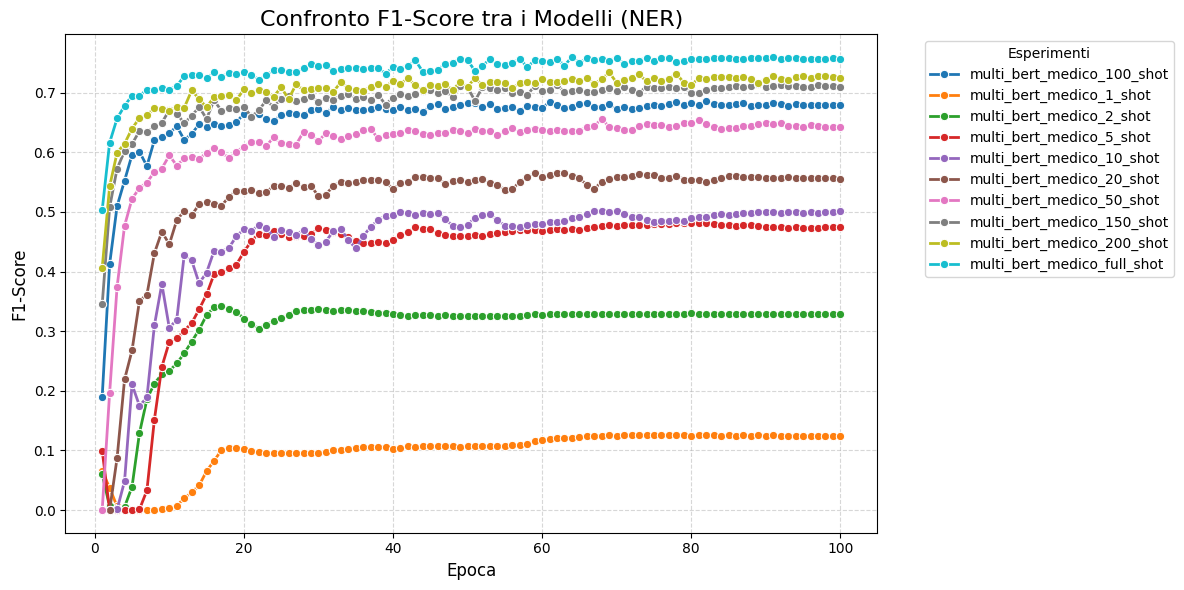

In [14]:
import wandb
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
api =wandb.Api()
project_path = "edoardotantari99-universit-di-bologna/clinical-ner-task"
runs = api.runs(project_path)

all_stats = []

for run in runs:
    # Prendiamo i grafici che ci interressano da wandb
    history = run.history(keys=["train/epoch", "eval/f1", "eval/loss"])
    
    if not history.empty:
        history["run_name"] = run.name
        all_stats.append(history)

# Creiamo il DataFrame unico
df_plot = pd.concat(all_stats, ignore_index=True)

df_clean = df_plot.dropna(subset=["eval/f1"])

# Grafico
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_clean, 
    x="train/epoch", 
    y="eval/f1", 
    hue="run_name", 
    marker="o", 
    linewidth=2
)

plt.title("Confronto F1-Score tra i Modelli (NER)", fontsize=16)
plt.xlabel("Epoca", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Esperimenti", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()





### Analisi delle Curve di Training: Impatto della Dimensione del Dataset (Multilingue)

Il grafico soprastante illustra l'andamento della metrica **F1-Score** sul Validation Set nel corso di 100 epoche di addestramento. Ogni curva rappresenta un diverso esperimento condotto sul modello pre-addestrato multilingua, variando esclusivamente il numero di documenti forniti in fase di *fine-tuning* (da 1 singolo documento fino all'intero set di addestramento "full-shot").

Dall'osservazione delle curve emergono tre dinamiche fondamentali:

* **1. Il limite dell'Extreme Few-Shot (1-shot e 2-shot):**
Le curve inferiori (arancione e verde) dimostrano i limiti statistici dei modelli Transformer in regimi di estrema scarsità di dati. Il modello `1_shot` rimane a un F1-Score di 0.0 per le prime 10 epoche (collasso sulla classe maggioritaria 'O'), faticando a estrarre pattern generali e assestandosi infine su un modesto **0.12**. Il `2_shot` mostra un miglioramento, ma si ferma poco sopra lo **0.30**. Manca la varianza linguistica necessaria per generalizzare.

* **2. Lo Scaling Lineare (5-shot fino a 50-shot):**
Tra i 5 e i 50 documenti si osserva una progressione quasi lineare delle performance. All'aumentare dei dati, il modello non solo raggiunge picchi di F1-Score progressivamente più alti (passando dallo **0.47** del `5_shot` allo **0.65** del `50_shot`), ma lo fa in modo molto più ripido nelle prime epoche, dimostrando che una base dati leggermente più ampia accelera drasticamente la fase iniziale di apprendimento.

* **3. Convergenza e Saturazione (100-shot al Full-Shot):**
Oltre i 100 documenti, subentra la legge dei rendimenti decrescenti. Le curve superiori (grigia, verde oliva e azzurra) sono molto vicine tra loro. Il modello `full_shot` (azzurro) definisce il "tetto massimo" per questa architettura su questo dataset, raggiungendo rapidamente la convergenza intorno all'epoca 15 e stabilizzandosi su un F1-Score di picco di circa **0.75**. 

**Conclusione:**
Le curve dimostrano chiaramente che bastano circa 150-200 documenti per ottenere performance quasi indistinguibili da quelle ottenibili con l'intero dataset. Inoltre, l'evidente appiattimento di tutte le curve dopo l'epoca 20-30 conferma l'assoluta necessità di stoppare il training anticipatamente.

C:\Users\mikeo\AppData\Local\Temp\ipykernel_4308\3990661079.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


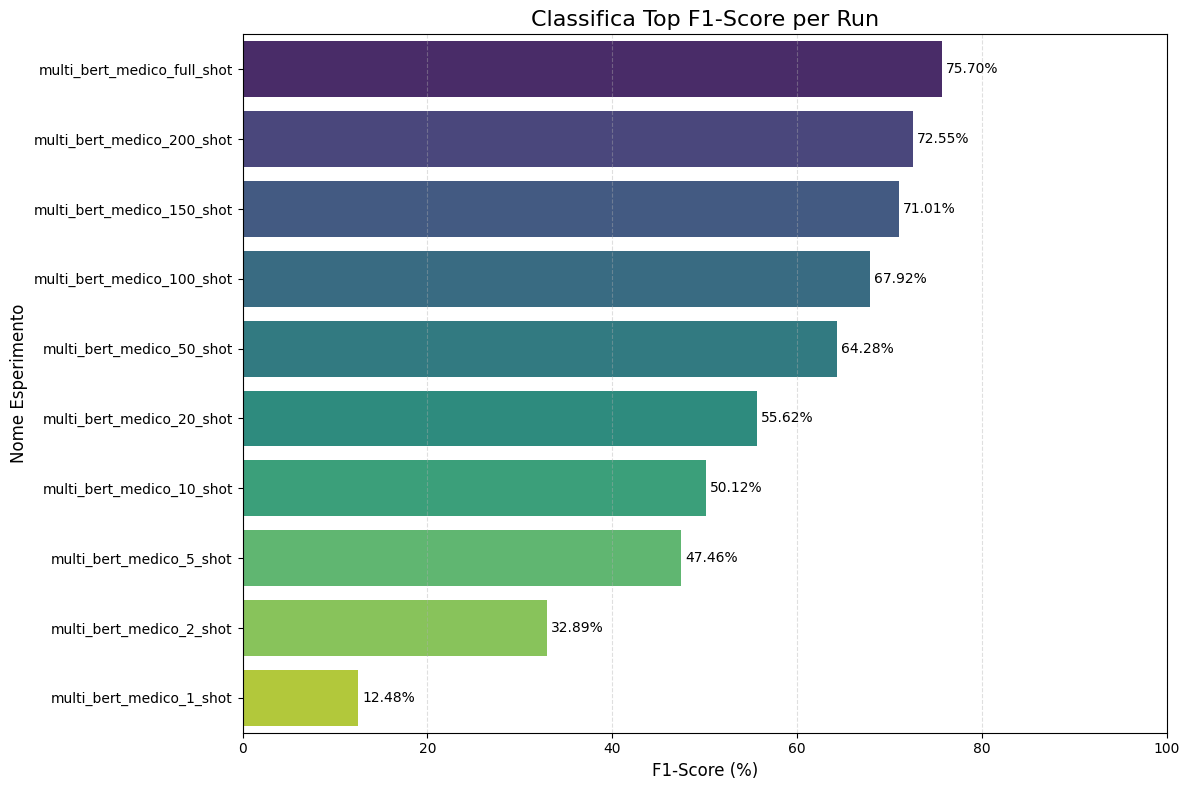

In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
api =wandb.Api()
project_path = "edoardotantari99-universit-di-bologna/clinical-ner-task"
runs = api.runs(project_path)

# Top F1 Score per Run
summary_list = []
for run in runs:
    f1_max = run.summary.get("eval/f1")
    
    if f1_max is not None:
        summary_list.append({
            "Modello": run.name,
            "Best F1-Score": f1_max * 100 if f1_max <= 1 else f1_max
        })


df_best = pd.DataFrame(summary_list)
df_best = df_best.sort_values(by="Best F1-Score", ascending=False)

#Generazione del Grafico a Barre
plt.figure(figsize=(12, 8))
plot = sns.barplot(
    data=df_best, 
    x="Best F1-Score", 
    y="Modello", 
    palette="viridis"
)

# Aggiungi le etichette con il valore esatto sopra ogni barra
for i in plot.containers:
    plot.bar_label(i, fmt='%.2f%%', padding=3)

plt.title("Classifica Top F1-Score per Run", fontsize=16)
plt.xlabel("F1-Score (%)", fontsize=12)
plt.ylabel("Nome Esperimento", fontsize=12)
plt.xlim(0, 100) 
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Classifica F1-Score

Il grafico a barre orizzontali soprastante condensa i risultati dell'analisi precedente, isolando esclusivamente il **miglior F1-Score** (picco massimo) registrato da ciascun modello durante l'intera fase di addestramento. Questa visualizzazione a "classifica" permette di quantificare in modo immediato il ritorno sull'investimento (ROI) derivante dall'aggiunta di nuovi dati annotati.

L'analisi dei picchi prestazionali evidenzia tre concetti chiave:

* **1. Il divario estremo tra One-Shot e Full-Shot:**
Il modello addestrato su un singolo documento (`1_shot`) si ferma a un **12.48%**, confermando l'incapacità della rete di inferire regole grammaticali complesse da un unico esempio. Sfruttando l'intero dataset multilingue (`full_shot`), il modello raggiunge invece il suo apice assoluto al **75.70%**, moltiplicando le performance di oltre 6 volte.

* **2. L'efficienza del Few-Shot Learning (Il "Punto di Flesso"):**
Il dato forse più interessante a livello ingegneristico è l'incredibile efficienza dei regimi intermedi. Fornendo solo 50 documenti (`50_shot`), il modello raggiunge già un F1-Score del **64.28%**. Questo significa che con una frazione minuscola del dataset totale, il *Transfer Learning* (sfruttando la pre-conoscenza di mBERT) riesce a garantire quasi l'85% delle performance massime ottenibili.

* **3. La Legge dei Rendimenti Decrescenti:**
Osservando la parte alta della classifica, si nota come l'incremento di performance diventi progressivamente più faticoso. Passare da 150 a 200 documenti porta un guadagno di appena l'**1.5%** (da 71.01% a 72.55%). Aggiungere i restanti documenti per arrivare al `full_shot` porta l'ultimo incremento al 75.70%. Questo dimostra che, superata una certa soglia critica di dati, il modello satura la sua capacità di apprendimento su questo specifico dominio.

**Conclusione Tecnica:**
Questa classifica conferma che, in scenari clinici reali dove l'annotazione manuale è costosa (medici esperti), non è necessario annotare migliaia di documenti. Un approccio misto basato su *Multilingual Pre-training* unito a un fine-tuning su un bacino ristretto di 100-150 referti (F1-Score ~68-71%) rappresenta il compromesso ideale tra costi di annotazione e qualità predittiva del sistema.

## Inferenza sui modelli BERT fine tunati

Nella seguente cella interattiva è implementata una piccola demo dove è possibile provare i modelli addestrati nella fase di training su file di testo medici mai visti o generati da un LLM (gemini, gpt).

Viene data la possibilità all'utente di inserire un testo fittizio oppure, premendo invio prendere un documento medico di default (file txt).

Successivamente il modello BERT selezionato restituisce in output, se presenti, i concetti di interesse clinico (sintomatologia e malattie) con una soglia maggiore o uguale del 80%.

In [2]:
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification


def file_to_string(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except FileNotFoundError:
        return "Error: file not found."
    except Exception as e:
        return f"Unexpected error: {e}"


# Set-Up

CARTELLA_MODELLO = "model\score_multi_bert_medico_full_shot_early" 
#MODEL_NAME = "dbmdz/bert-base-italian-cased"
MODEL_NAME = "bert-base-multilingual-cased"
#MODEL_NAME = "xlm-roberta-large"

print(f"Caricamento del modello da: {CARTELLA_MODELLO}...")

# tokenizer e modello
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
modello = AutoModelForTokenClassification.from_pretrained(CARTELLA_MODELLO)

# HuggingFace Pipeline
# aggregation_strategy="simple" unisce in automatico i sub-token ("elettro" + "##cardio")
ner_pipeline = pipeline("token-classification", model=modello, tokenizer=tokenizer, aggregation_strategy="simple")

print("\nScrivi un referto medico inventato (o premi Invio per usare l'esempio).")

testo_input = input("\nReferto: ")

    
if not testo_input.strip():
    # predef input file
    testo_input = file_to_string("example/fr_example.txt")
    print(f"Uso l'esempio: {testo_input}")

# Inference
risultati = ner_pipeline(testo_input)

print(f"\n--- Risultati Pipeline : \n{risultati}\n\n")
if not risultati:
    print("Nessuna entità clinica trovata.")
else:
    for entita in risultati:
        parola = entita['word']
        etichetta = entita['entity_group']
        score = entita['score'] * 100

        
        print(f" Trovato: '{parola}'")
        print(f"   Tipo: {etichetta} (Score del modello: {score:.5f} %)\n")

Caricamento del modello da: model\score_multi_bert_medico_full_shot_early...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Scrivi un referto medico inventato (o premi Invio per usare l'esempio).
Uso l'esempio: Rapport médical

Le patient, André Martin, âgé de 64 ans, consulte pour une fatigue intense et persistante, une douleur thoracique intermittente, des troubles respiratoires progressifs et des douleurs abdominales récurrentes. Il présente des antécédents d’hypertension artérielle, d’insuffisance cardiaque chronique, de diabète de type 2, d’insuffisance rénale modérée et d’arthrose lombaire. Depuis plusieurs semaines, il décrit une aggravation de l’essoufflement à l’effort, des épisodes de palpitations, un gonflement des membres inférieurs, ainsi qu’une prise de poids récente associée à une rétention hydrique. Il rapporte également une toux productive avec expectorations blanchâtres, des sifflements respiratoires nocturnes et une sensation d’oppression thoracique.

Sur le plan digestif, le patient mentionne des brûlures rétro-sternales, des douleurs épigastriques après les repas, des nausées occasionn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


#Plotting
sns.set_theme(style="whitegrid", font_scale=1.1)

esperimenti = [
    "One-Shot\n(Italiano)", 
    "Few-Shot (10)\n(Italiano)", 
    "Full-Shot\n(Italiano)", 
    "mBERT\n(Multilingue)", 
    "XLM-RoBERTa\n(Multilingue)"
]

f1_scores = [0.00, 0.46, 0.60, 0.64, 0.67]


colori = ['#e74c3c', '#3498db', '#2980b9', '#f39c12', '#27ae60']


plt.figure(figsize=(11, 6)) 
bars = plt.bar(esperimenti, f1_scores, color=colori)

plt.ylim(0, 0.8) 
plt.ylabel("Metrica F1-Score", fontsize=12, fontweight='bold')
plt.title("Evoluzione delle Performance NER Clinico (Knowledge Representation)", fontsize=16, fontweight='bold', pad=20)

for bar in bars:
    altezza = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, altezza + 0.01, 
             f"{altezza:.2f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.plot(esperimenti, f1_scores, color='gray', linestyle='--', marker='o', alpha=0.5)

plt.tight_layout()
nome_file = 'grafico_risultati_esame.png'
plt.savefig(nome_file, dpi=300) 
print(f"Grafico salvato con successo come: {nome_file}")